In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

PASTA = "/content/drive/MyDrive/CFEM Minas Gerais"
os.makedirs(f"{PASTA}/graficos", exist_ok=True)
print(f"✅ Drive montado.")


Mounted at /content/drive
✅ Drive montado.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

df_mg = pd.read_csv(f"{PASTA}/dados_processados/cfem_mg_limpo.csv")
print(f"Registros MG: {len(df_mg):,}")
print(f"Período: {df_mg['Ano'].min()} – {df_mg['Ano'].max()}")
df_mg.head(3)


Registros MG: 192,898
Período: 2017 – 2026


,Ano,Mês,Processo,AnoDoProcesso,Tipo_PF_PJ,CPF_CNPJ,Substância,UF,CodigoMunicipio,Município,QuantidadeComercializada,UnidadeDeMedida,ValorRecolhido,DataCriacao,Periodo
0,2017,1,831048.0,2001.0,PJ,366593000104,AREIA,MG,3139003,MACHADO,18.108,t,445.16,2017-01-02 07:51:00,2017-2021
1,2017,1,832665.0,1995.0,PJ,967184000163,FILITO,MG,3131901,ITABIRITO,1.094,t,3370.55,2017-01-02 15:11:00,2017-2021
2,2017,1,933838.0,2011.0,PJ,1590773000138,ÁGUA MINERAL,MG,3115102,CÁSSIA,0.0,l,650.75,2013-01-28 14:37:00,2017-2021


In [ ]:
def ranking_periodo(df, periodo, top_n=15):

    sub  = df[df['Periodo'] == periodo]
    rank = (sub.groupby('Município')['ValorRecolhido']
               .sum().sort_values(ascending=False)
               .head(top_n).reset_index())
    rank.columns = ['Município', 'CFEM_Total']
    rank['Rank']    = range(1, len(rank) + 1)
    rank['CFEM_Bi'] = rank['CFEM_Total'] / 1e9
    rank['Período'] = periodo
    return rank

rank_1721 = ranking_periodo(df_mg, '2017-2021')
rank_2226 = ranking_periodo(df_mg, '2022-2026')

print("Top 15 — 2017-2021:")
print(rank_1721[['Rank','Município','CFEM_Bi']].to_string(index=False))
print()
print("Top 15 — 2022-2026:")
print(rank_2226[['Rank','Município','CFEM_Bi']].to_string(index=False))


Top 15 — 2017-2021:
 Rank                 Município  CFEM_Bi
    1                 CONGONHAS 1.371789
    2  CONCEIÇÃO DO MATO DENTRO 1.305125
    3                   ITABIRA 1.103783
    4                 ITABIRITO 1.074443
    5                 NOVA LIMA 1.010844
    6                   MARIANA 0.831446
    7 SÃO GONÇALO DO RIO ABAIXO 0.823941
    8                 BELO VALE 0.463037
    9                ITATIAIUÇU 0.445645
   10                BRUMADINHO 0.419492
   11                  PARACATU 0.271497
   12                OURO PRETO 0.186445
   13               CATAS ALTAS 0.148553
   14            RIO PIRACICABA 0.147157
   15                    SABARÁ 0.135571

Top 15 — 2022-2026:
 Rank                 Município  CFEM_Bi
    1  CONCEIÇÃO DO MATO DENTRO 1.726266
    2                 CONGONHAS 1.391359
    3                 ITABIRITO 1.297731
    4                   ITABIRA 1.283278
    5                   MARIANA 1.203263
    6 SÃO GONÇALO DO RIO ABAIXO 1.178340
    7           

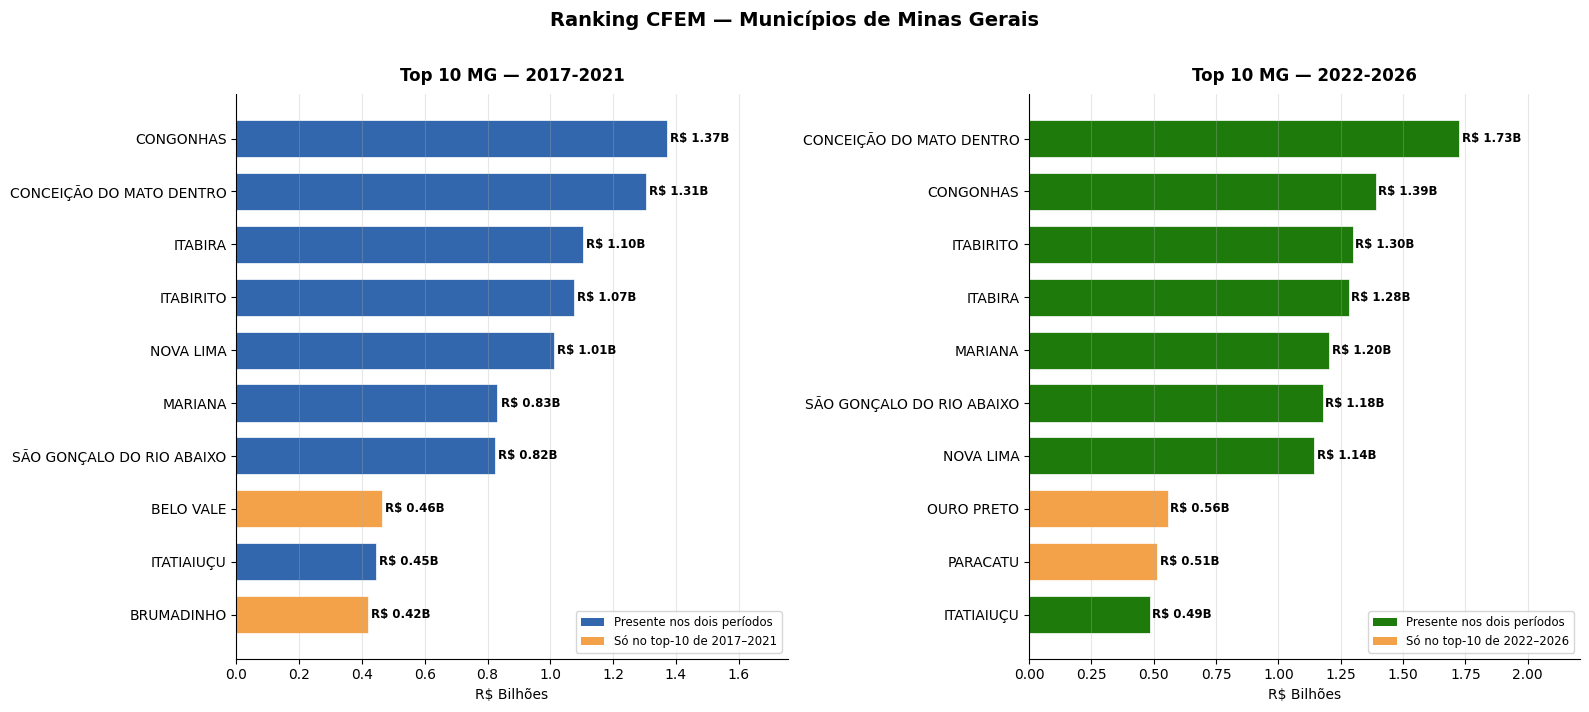

Gráfico salvo no Drive ✅


In [ ]:
top10_1721 = set(rank_1721.head(10)['Município'])
top10_2226 = set(rank_2226.head(10)['Município'])
novos_1721 = top10_1721 - top10_2226
novos_2226 = top10_2226 - top10_1721

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, periodo, rank, cor_base, novos, novos_label in [
    (axes[0], '2017-2021', rank_1721, '#3266ad', novos_1721, 'Só no top-10 de 2017–2021'),
    (axes[1], '2022-2026', rank_2226, '#1E7A0A', novos_2226, 'Só no top-10 de 2022–2026'),
]:
    r10   = rank.head(10).iloc[::-1]
    cores = ['#F4A24A' if m in novos else cor_base for m in r10['Município']]
    bars  = ax.barh(r10['Município'], r10['CFEM_Bi'],
                    color=cores, edgecolor='white', linewidth=0.5, height=0.7)
    for bar, val in zip(bars, r10['CFEM_Bi']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'R$ {val:.2f}B', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(f'Top 10 MG — {periodo}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('R$ Bilhões', fontsize=10)
    ax.set_xlim(0, r10['CFEM_Bi'].max() * 1.28)
    ax.grid(axis='x', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    ax.legend(handles=[
        mpatches.Patch(facecolor=cor_base,  label='Presente nos dois períodos'),
        mpatches.Patch(facecolor='#F4A24A', label=novos_label),
    ], fontsize=8.5, loc='lower right')

plt.suptitle('Ranking CFEM — Municípios de Minas Gerais', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb2_ranking_comparativo.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


In [ ]:
bh = df_mg[df_mg['Município'] == 'BELO HORIZONTE']
bh_ano  = bh.groupby('Ano')['ValorRecolhido'].sum()
bh_1721 = bh[bh['Periodo']=='2017-2021']['ValorRecolhido'].sum()
bh_2226 = bh[bh['Periodo']=='2022-2026']['ValorRecolhido'].sum()

print("Arrecadação de Belo Horizonte por ano:")
for ano, val in bh_ano.items():
    print(f"  {ano}: R$ {val/1e3:,.0f} mil")

top1_1721 = rank_1721.iloc[0]['CFEM_Total']
top1_2226 = rank_2226.iloc[0]['CFEM_Total']
print(f"\nTotal 2017-2021: R$ {bh_1721/1e3:,.0f} mil")
print(f"Total 2022-2026: R$ {bh_2226/1e3:,.0f} mil")
print(f"\nBH = {bh_1721/top1_1721*100:.4f}% do 1º colocado em 2017-2021")
print(f"BH = {bh_2226/top1_2226*100:.4f}% do 1º colocado em 2022-2026")
print("\n→ Mineração não é atividade relevante em BH (metrópole de serviços).")


Arrecadação de Belo Horizonte por ano:
  2017: R$ 3,698 mil
  2018: R$ 56 mil
  2019: R$ 9 mil
  2020: R$ 19 mil
  2021: R$ 4 mil
  2022: R$ 2 mil
  2023: R$ 84 mil
  2024: R$ 711 mil
  2025: R$ 3 mil
  2026: R$ 1 mil

Total 2017-2021: R$ 3,785 mil
Total 2022-2026: R$ 801 mil

BH = 0.2759% do 1º colocado em 2017-2021
BH = 0.0464% do 1º colocado em 2022-2026

→ Mineração não é atividade relevante em BH (metrópole de serviços).


In [ ]:
for periodo in ['2017-2021', '2022-2026']:
    rank_full = ranking_periodo(df_mg, periodo, top_n=900)
    total     = rank_full['CFEM_Total'].sum()
    rank_full['Part_Acum%'] = rank_full['CFEM_Total'].cumsum() / total * 100
    n80    = int((rank_full['Part_Acum%'] < 80).sum()) + 1
    n95    = int((rank_full['Part_Acum%'] < 95).sum()) + 1
    ativos = (rank_full['CFEM_Total'] > 0).sum()
    top1   = rank_full.iloc[0]
    print(f"\n{periodo}:")
    print(f"  Municípios com arrecadação > 0 : {ativos}")
    print(f"  Para atingir 80% da arrecadação: {n80} municípios")
    print(f"  Para atingir 95% da arrecadação: {n95} municípios")
    print(f"  1º lugar ({top1['Município'].title()}): {top1['Part_Acum%']:.1f}% do total")
    print(f"  Top 10 juntos: {rank_full.head(10)['CFEM_Total'].sum()/total*100:.1f}% do total")



2017-2021:
  Municípios com arrecadação > 0 : 587
  Para atingir 80% da arrecadação: 10 municípios
  Para atingir 95% da arrecadação: 25 municípios
  1º lugar (Congonhas): 12.6% do total
  Top 10 juntos: 81.3% do total

2022-2026:
  Municípios com arrecadação > 0 : 606
  Para atingir 80% da arrecadação: 12 municípios
  Para atingir 95% da arrecadação: 28 municípios
  1º lugar (Conceição Do Mato Dentro): 12.0% do total
  Top 10 juntos: 75.1% do total


In [ ]:
merged = (rank_1721[['Município','Rank']].rename(columns={'Rank':'Rank_1721'})
          .merge(rank_2226[['Município','Rank']].rename(columns={'Rank':'Rank_2226'}),
                 on='Município', how='outer'))
merged['Variação'] = merged['Rank_1721'] - merged['Rank_2226']
merged['Direção']  = merged['Variação'].apply(
    lambda x: '▲ Subiu' if pd.notna(x) and x > 0
              else ('▼ Caiu' if pd.notna(x) and x < 0
              else ('= Igual' if pd.notna(x) else '— Novo no ranking')))
merged = merged.sort_values('Rank_2226').fillna('—')
print(merged.to_string(index=False))


                Município Rank_1721 Rank_2226 Variação           Direção
 CONCEIÇÃO DO MATO DENTRO       2.0       1.0      1.0           ▲ Subiu
                CONGONHAS       1.0       2.0     -1.0            ▼ Caiu
                ITABIRITO       4.0       3.0      1.0           ▲ Subiu
                  ITABIRA       3.0       4.0     -1.0            ▼ Caiu
                  MARIANA       6.0       5.0      1.0           ▲ Subiu
SÃO GONÇALO DO RIO ABAIXO       7.0       6.0      1.0           ▲ Subiu
                NOVA LIMA       5.0       7.0     -2.0            ▼ Caiu
               OURO PRETO      12.0       8.0      4.0           ▲ Subiu
                 PARACATU      11.0       9.0      2.0           ▲ Subiu
               ITATIAIUÇU       9.0      10.0     -1.0            ▼ Caiu
                BELO VALE       8.0      11.0     -3.0            ▼ Caiu
               BRUMADINHO      10.0      12.0     -2.0            ▼ Caiu
          BARÃO DE COCAIS         —      13.0      

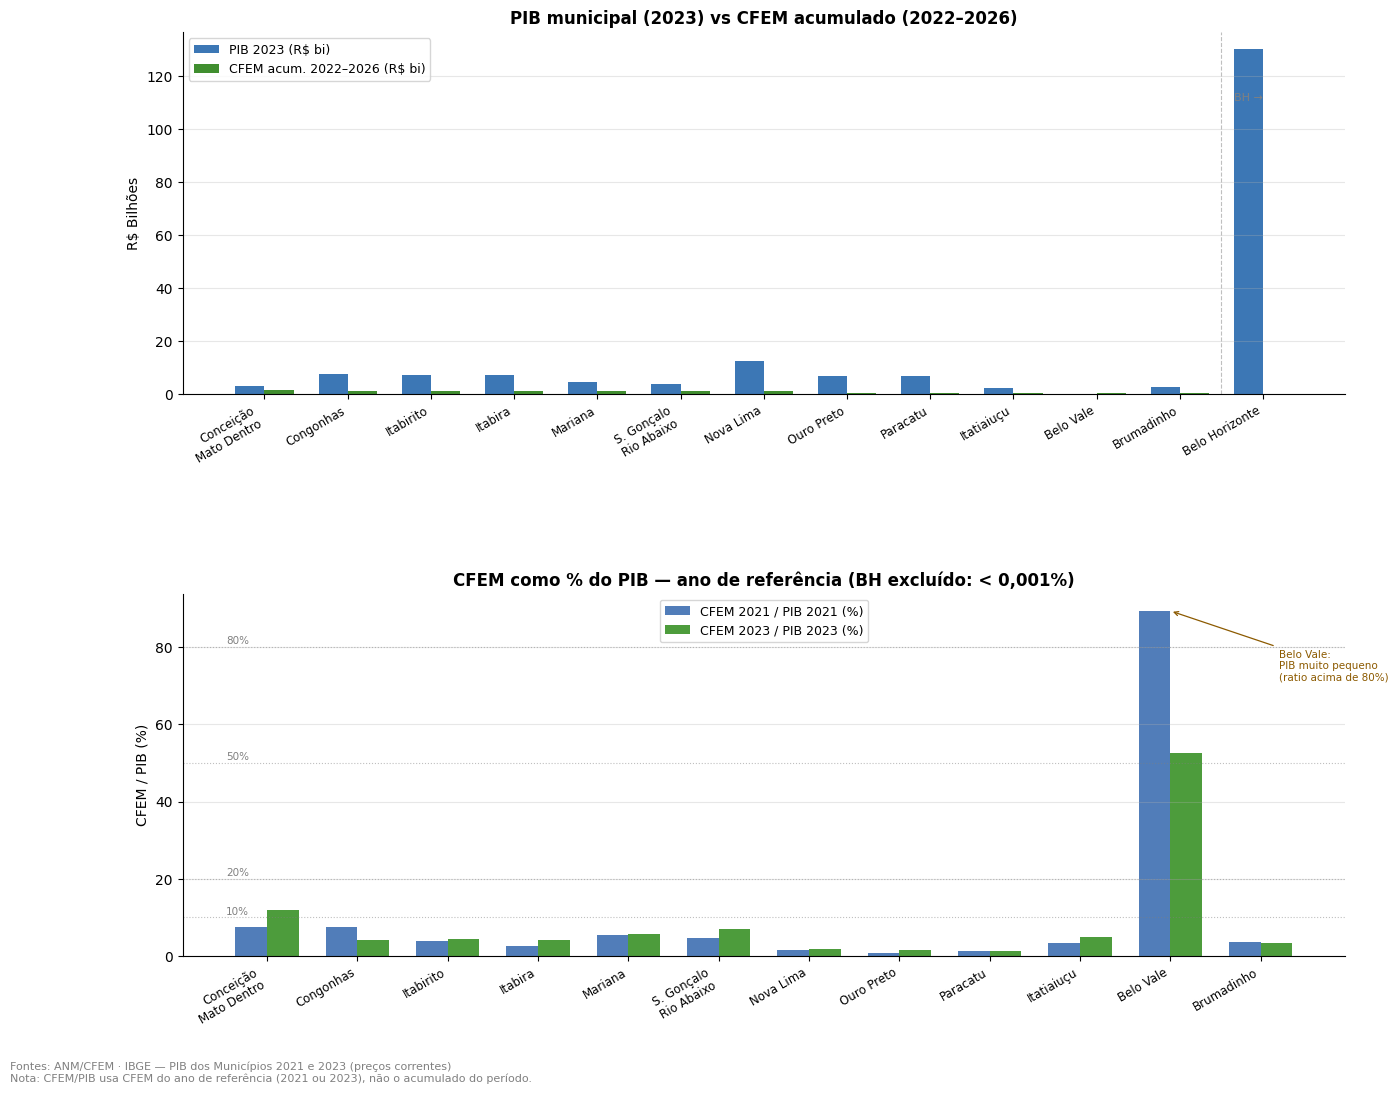

Gráfico salvo no Drive ✅


In [ ]:
pib = pd.DataFrame([
    ("Conceição do Mato Dentro",   9_050_952,   3_194_401),
    ("Congonhas",                  7_677_447,   7_693_794),
    ("Itabirito",                 13_139_282,   7_160_444),
    ("Itabira",                   14_971_550,   7_434_200),
    ("Mariana",                    7_367_033,   4_656_946),
    ("São Gonçalo do Rio Abaixo",  7_603_788,   3_766_222),
    ("Nova Lima",                 21_040_766,  12_447_551),
    ("Ouro Preto",                 9_518_797,   6_765_810),
    ("Paracatu",                   7_198_751,   6_798_922),
    ("Itatiaiuçu",                 6_934_362,   2_434_575),
    ("Brumadinho",                 4_624_729,   2_845_330),
    ("Belo Vale",                    279_868,     268_616),
    ("Belo Horizonte",           105_920_859, 130_197_671),
], columns=["municipio", "pib_2021_mil", "pib_2023_mil"])

cfem_ref = pd.DataFrame([
    ("Conceição do Mato Dentro",  668_800,  382_200),
    ("Congonhas",                 569_500,  309_100),
    ("Itabirito",                 522_700,  319_400),
    ("Itabira",                   395_100,  301_700),
    ("Mariana",                   398_300,  260_100),
    ("São Gonçalo do Rio Abaixo", 346_600,  266_600),
    ("Nova Lima",                 324_400,  240_400),
    ("Ouro Preto",                 68_300,  107_800),
    ("Paracatu",                   84_200,   93_200),
    ("Itatiaiuçu",                229_600,  117_100),
    ("Brumadinho",                164_700,   98_000),
    ("Belo Vale",                 250_100,  140_900),
    ("Belo Horizonte",                  0,      100),
], columns=["municipio", "cfem_2021_mil", "cfem_2023_mil"])

cfem_acum = pd.DataFrame([
    ("Conceição do Mato Dentro",  1_305_125, 1_726_266),
    ("Congonhas",                 1_371_789, 1_391_359),
    ("Itabirito",                 1_074_443, 1_297_731),
    ("Itabira",                   1_103_783, 1_283_278),
    ("Mariana",                     831_446, 1_203_263),
    ("São Gonçalo do Rio Abaixo",   823_941, 1_178_340),
    ("Nova Lima",                 1_010_844, 1_143_926),
    ("Ouro Preto",                  186_445,   555_527),
    ("Paracatu",                    271_497,   513_488),
    ("Itatiaiuçu",                  445_645,   485_059),
    ("Brumadinho",                  419_492,   416_504),
    ("Belo Vale",                   463_037,   467_681),
    ("Belo Horizonte",                3_785,       801),
], columns=["municipio", "acum_1721_mil", "acum_2226_mil"])

df = pib.merge(cfem_ref, on="municipio").merge(cfem_acum, on="municipio")
df["ratio_2021"] = df["cfem_2021_mil"] / df["pib_2021_mil"] * 100
df["ratio_2023"] = df["cfem_2023_mil"] / df["pib_2023_mil"] * 100

bh  = df[df["municipio"] == "Belo Horizonte"]
df  = pd.concat([
    df[df["municipio"] != "Belo Horizonte"].sort_values("acum_2226_mil", ascending=False),
    bh
]).reset_index(drop=True)

muns = (df["municipio"]
        .str.replace("São Gonçalo do Rio Abaixo", "S. Gonçalo\nRio Abaixo", regex=False)
        .str.replace("Conceição do Mato Dentro",  "Conceição\nMato Dentro",  regex=False))
x = np.arange(len(df))
w = 0.35

fig, axes = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={"hspace": 0.55})

ax1 = axes[0]
ax1.bar(x - w/2, df["pib_2023_mil"]/1e6,  width=w, color="#1A5FA8",
        alpha=0.85, label="PIB 2023 (R$ bi)")
ax1.bar(x + w/2, df["acum_2226_mil"]/1e6, width=w, color="#1E7A0A",
        alpha=0.85, label="CFEM acum. 2022–2026 (R$ bi)")

ax1.axvline(x=len(df)-1.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.text(len(df)-1.35, df["pib_2023_mil"].max()/1e6 * 0.85, "BH →", fontsize=8, color="gray")

ax1.set_xticks(x); ax1.set_xticklabels(muns, fontsize=8.5, rotation=30, ha="right")
ax1.set_ylabel("R$ Bilhões", fontsize=10)
ax1.set_title("PIB municipal (2023) vs CFEM acumulado (2022–2026)", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(axis="y", alpha=0.3)
ax1.spines[["top","right"]].set_visible(False)

ax2 = axes[1]
df2   = df[df["municipio"] != "Belo Horizonte"].reset_index(drop=True)
muns2 = (df2["municipio"]
         .str.replace("São Gonçalo do Rio Abaixo", "S. Gonçalo\nRio Abaixo", regex=False)
         .str.replace("Conceição do Mato Dentro",  "Conceição\nMato Dentro",  regex=False))
x2 = np.arange(len(df2))

ax2.bar(x2 - w/2, df2["ratio_2021"], width=w, color="#3266ad",
        alpha=0.85, label="CFEM 2021 / PIB 2021 (%)")
ax2.bar(x2 + w/2, df2["ratio_2023"], width=w, color="#2E8B1A",
        alpha=0.85, label="CFEM 2023 / PIB 2023 (%)")

for ref in [10, 20, 50, 80]:
    ax2.axhline(ref, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    ax2.text(-0.45, ref + 0.8, f"{ref}%", fontsize=7.5, color="gray")

idx_bv   = df2["municipio"].tolist().index("Belo Vale")
bv_r2021 = df2.loc[idx_bv, "ratio_2021"]
bv_r2023 = df2.loc[idx_bv, "ratio_2023"]
ax2.annotate(
    """Belo Vale:
PIB muito pequeno
(ratio acima de 80%)""",
    xy=(idx_bv, bv_r2021), xytext=(idx_bv + 1.2, bv_r2021 - 18),
    fontsize=7.5, color="#8C5A00",
    arrowprops=dict(arrowstyle="->", color="#8C5A00", lw=0.9))

ax2.set_xticks(x2); ax2.set_xticklabels(muns2, fontsize=8.5, rotation=30, ha="right")
ax2.set_ylabel("CFEM / PIB (%)", fontsize=10)
ax2.set_title("CFEM como % do PIB — ano de referência (BH excluído: < 0,001%)",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(axis="y", alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

fig.text(0.01, 0.005,
    "Fontes: ANM/CFEM · IBGE — PIB dos Municípios 2021 e 2023 (preços correntes)\n"
    "Nota: CFEM/PIB usa CFEM do ano de referência (2021 ou 2023), não o acumulado do período.",
    fontsize=8, color="gray")

plt.savefig(f"{PASTA}/graficos/nb2_cfem_vs_pib.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo no Drive ✅")

In [ ]:
print("=" * 72)
print(f"{'Município':<30} {'PIB 2023':>11} {'CFEM 2023':>11} {'CFEM/PIB':>10} {'CFEM acum.':>11}")
print(f"{'':30} {'(R$ bi)':>11} {'(R$ mi)':>11} {'(%)':>10} {'2022-26 bi':>11}")
print("=" * 72)
for _, row in df.iterrows():
    print(f"{row['municipio']:<30} "
          f"{row['pib_2023_mil']/1e6:>11.2f} "
          f"{row['cfem_2023_mil']/1e3:>11.1f} "
          f"{row['ratio_2023']:>9.2f}% "
          f"{row['acum_2226_mil']/1e6:>11.3f}")
